In [1]:
# forçando o repositorio a encontrar src
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
import pandas as pd 
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#from utils.analytics.Plot3d import Plot3d

In [3]:
# funçao de diferença logaritmica
def log_diff(X:pd.Series):
    return np.log(X).diff()

In [4]:
x_train_path = os.path.join('..','..', 'data', 'processed', 'dados_treino.csv')
X_train = pd.read_csv(x_train_path)
X_train.shape

(166, 7)

In [5]:
# vetor resposta 
y_train_path = os.path.join('..', '..','data', 'processed', 'vetor_resposta.csv')
y_train = pd.read_csv(y_train_path)
y_train = y_train.set_index('data')
y_train

,Inadimplencia_PF
data,
2012-03-01,5.36
2012-04-01,5.41
2012-05-01,5.51
2012-06-01,5.43
2012-07-01,5.42
...,...
2025-09-01,4.89
2025-10-01,4.99
2025-11-01,5.12


In [6]:
X_train = X_train.dropna()

In [7]:
X_train.isnull().sum()

intercepto                    0
Confiança_consumidor          0
Desemprego                    0
SELIC                         0
IBC-Br                        0
IPCA                          0
Endividamento_das_familias    0
dtype: int64

In [8]:
X_train = X_train.dropna()
X_train

,intercepto,Confiança_consumidor,Desemprego,SELIC,IBC-Br,IPCA,Endividamento_das_familias
0,1,0.024095,7.366499,0.741320,0.003247,0.527917,37.111279
1,1,0.040457,7.443742,0.734245,0.012553,0.454032,37.259476
2,1,-0.017547,7.412833,0.659889,0.007148,0.285128,37.425464
3,1,0.010836,7.332529,0.621403,0.001709,0.689960,37.483668
4,1,-0.029887,7.280069,0.674989,0.002983,0.656219,37.587446
...,...,...,...,...,...,...,...
161,1,-0.014982,5.755866,1.221394,-0.001507,0.478253,49.138474
162,1,0.028579,5.654327,1.224007,0.000731,0.116143,49.388298
163,1,0.026956,5.515957,1.142840,0.005121,0.219613,49.537583
164,1,0.017922,5.372552,1.209036,0.001313,0.226347,49.701265


In [9]:
# criando funçao para previsao direta do modelo
def model_MQO(X:pd.DataFrame):
    return 8.025793 +  1.721968 *X['Confiança_consumidor'] + -0.149354 *X['Desemprego'] + 0.240921*X['SELIC'] + 2.644685 *X['IBC-Br'] + -0.240376*X['IPCA'] + -0.063539 *X['Endividamento_das_familias']

In [10]:
# fazendo previsoes
y_pred_train = model_MQO(X_train)


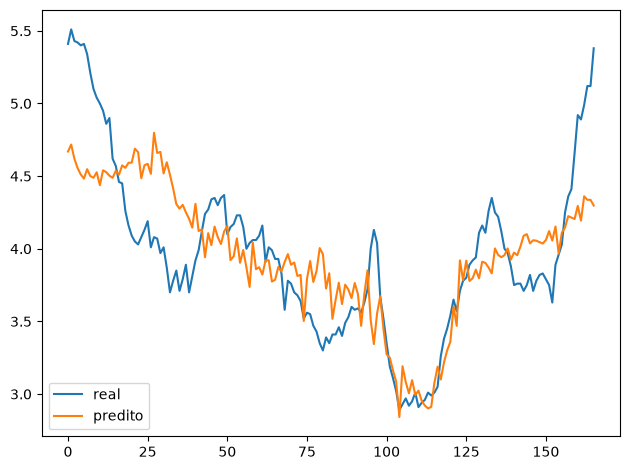

In [11]:
y_train_alinhado = y_train.iloc[-len(y_pred_train):]
y_train_alinhado = y_train_alinhado.squeeze()
y_train_alinhado = y_train_alinhado.reset_index(drop=True)
y_train_alinhado = pd.Series(y_train_alinhado)
plt.plot(X_train.index, y_train_alinhado, label='real')
plt.plot(X_train.index, y_pred_train, label='predito')
plt.tight_layout()
plt.legend()
plt.show()

In [12]:
resid = y_train_alinhado - y_pred_train

In [13]:
print(f'média dos residuos: {resid.mean()}')
print()
print(f'desvio padrao: {resid.std()}')

média dos residuos: 0.0050925310273928215

desvio padrao: 0.38477756698843774
